In [1]:
# 1. Imports
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, econometrics, config

target_volatility = 'Sq_Log_Return'

macro_shocks = ['CPI_Surprise', 'PPI_Surprise', 'FedFunds_Diff'] # The Inflation & Policy Block
# macro_shocks = ['Unemployment_Surprise', 'Housing_Starts_Surprise'] # The Real Economy Block
# macro_shocks = ['Trade_Balance_Surprise', 'M1_Money_Surprise'] # The Global & Liquidity Block
# macro_shocks = ['NFP_Suprise', 'Retail_Sales_Suprise']

raw_data_dict = data_loader.fetch_raw_data()

# Dictionaries to store our multi-sector results
sector_models = {}
sector_stats = {}
sector_var_data = {}

2026-06-21 22:57:28 - src.data_loader - INFO - Config parameters changed. Cache invalidated. Forcing refresh...
2026-06-21 22:57:28 - src.data_loader - INFO - Fetching fresh multi-sector data from APIs...
2026-06-21 22:57:29 - src.data_loader - INFO - Downloading historical data for XLK...
2026-06-21 22:57:29 - src.data_loader - INFO - Downloading historical data for XLE...
2026-06-21 22:57:30 - src.data_loader - INFO - Downloading historical data for XLF...
2026-06-21 22:57:31 - src.data_loader - INFO - Downloading historical data for XLV...


In [2]:
# 2. Multi-Sector Processing Loop
for etf in config.TARGET_ETFS:
    print(f"\n" + "="*50)
    print(f"PROCESSING SECTOR: {etf}")
    print("="*50)
    
    # Engineer Features
    raw_df = raw_data_dict[etf]
    stat_df = features.engineer_stationary_features(raw_df, etf_name=etf)
    
    # Prepare VAR Data
    var_data = econometrics.prepare_var_data(stat_df, target_vol_col=target_volatility, macro_cols=macro_shocks)
    sector_var_data[etf] = var_data
    
    # Granger Causality
    econometrics.test_granger_causality(var_data, sector_name=etf, max_lag=5)
    
    # Fit VAR Model (Only printing AIC table for the first ETF to save space)
    print(f"\nFitting VAR Model for {etf}...")
    is_first = (etf == config.TARGET_ETFS[0])
    results, optimal_lag = econometrics.fit_var_model(var_data, max_lags=9, verbose=is_first)
    
    sector_models[etf] = results
    
    # Extract Equation Stats
    stats_df = econometrics.get_equation_stats(results, target_vol_col=target_volatility)
    sector_stats[etf] = stats_df


2026-06-21 22:57:31 - src.features - INFO - Engineering features and macro surprises for XLK...
2026-06-21 22:57:31 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLK

--- Granger Causality: Macro -> XLK ---
[CPI_Surprise]
  Lag 1: p-value = 0.0207 **
  Lag 2: p-value = 0.1753 
  Lag 3: p-value = 0.4097 
  Lag 4: p-value = 0.7066 
  Lag 5: p-value = 0.8356 
[PPI_Surprise]
  Lag 1: p-value = 0.0002 ***
  Lag 2: p-value = 0.0125 **
  Lag 3: p-value = 0.0637 *
  Lag 4: p-value = 0.2301 
  Lag 5: p-value = 0.5242 
[FedFunds_Diff]
  Lag 1: p-value = 0.0180 **
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0001 ***
  Lag 4: p-value = 0.0002 ***
  Lag 5: p-value = 0.0002 ***

Fitting VAR Model for XLK...


2026-06-21 22:57:35 - src.features - INFO - Engineering features and macro surprises for XLE...
2026-06-21 22:57:35 - src.features - INFO - Calculating Autoregressive Macro Surprises...



LAG SELECTION CRITERIA
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -19.24      -19.23   4.419e-09      -19.24
1      -24.42      -24.39   2.492e-11      -24.41
2      -25.09     -25.05*   1.273e-11      -25.07
3      -25.09      -25.04   1.267e-11      -25.07
4      -25.10      -25.03   1.252e-11      -25.08
5      -25.12      -25.03   1.236e-11      -25.09
6      -25.13      -25.03   1.219e-11      -25.09
7      -25.14      -25.02   1.210e-11      -25.10
8      -25.15      -25.01   1.201e-11      -25.10
9     -25.17*      -25.01  1.175e-11*     -25.11*
-------------------------------------------------

PROCESSING SECTOR: XLE

--- Granger Causality: Macro -> XLE ---
[CPI_Surprise]
  Lag 1: p-value = 0.0119 **
  Lag 2: p-value = 0.0226 **
  Lag 3: p-value = 0.0871 *
  Lag 4: p-value = 0.3392 
  Lag 5: p-value = 0.5300 
[PPI_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-

2026-06-21 22:57:38 - src.features - INFO - Engineering features and macro surprises for XLF...
2026-06-21 22:57:38 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLF

--- Granger Causality: Macro -> XLF ---
[CPI_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0000 ***
  Lag 5: p-value = 0.0000 ***
[PPI_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0000 ***
  Lag 5: p-value = 0.0000 ***
[FedFunds_Diff]
  Lag 1: p-value = 0.3611 
  Lag 2: p-value = 0.1928 
  Lag 3: p-value = 0.0507 *
  Lag 4: p-value = 0.4022 
  Lag 5: p-value = 0.0911 *

Fitting VAR Model for XLF...


2026-06-21 22:57:42 - src.features - INFO - Engineering features and macro surprises for XLV...
2026-06-21 22:57:42 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLV

--- Granger Causality: Macro -> XLV ---
[CPI_Surprise]
  Lag 1: p-value = 0.0715 *
  Lag 2: p-value = 0.4637 
  Lag 3: p-value = 0.4946 
  Lag 4: p-value = 0.6488 
  Lag 5: p-value = 0.8507 
[PPI_Surprise]
  Lag 1: p-value = 0.0001 ***
  Lag 2: p-value = 0.0432 **
  Lag 3: p-value = 0.0688 *
  Lag 4: p-value = 0.1218 
  Lag 5: p-value = 0.3092 
[FedFunds_Diff]
  Lag 1: p-value = 0.1174 
  Lag 2: p-value = 0.0009 ***
  Lag 3: p-value = 0.0055 ***
  Lag 4: p-value = 0.0135 **
  Lag 5: p-value = 0.0001 ***

Fitting VAR Model for XLV...


In [3]:
# 3. SIDE-BY-SIDE EQUATION COMPARISON
print("\n" + "="*80)
print("MULTI-SECTOR VAR EQUATION COMPARISON")
print("="*80)
# This magical pandas function stitches all the sector tables together side-by-side
combined_stats = pd.concat(sector_stats.values(), axis=1, keys=sector_stats.keys())
display(combined_stats.fillna('-'))


MULTI-SECTOR VAR EQUATION COMPARISON


XLK                  XLE                  XLF          \
                    Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   P-Val   
const             0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001  0.0000   
L1.CPI_Surprise  -0.0000  0.5638       0.0001  0.3700       0.0002  0.0138   
L1.PPI_Surprise  -0.0000  0.9264      -0.0000  0.7595      -0.0000  0.1144   
L1.FedFunds_Diff -0.0002  0.3873       0.0004  0.1828       0.0004  0.1267   
L1.Sq_Log_Return  0.1435  0.0000  *** -0.0059  0.6333       0.1355  0.0000   
L2.CPI_Surprise   0.0000  0.6436      -0.0002  0.1204      -0.0002  0.0985   
L2.PPI_Surprise   0.0000  0.6612       0.0000  0.6885       0.0000  0.5063   
L2.FedFunds_Diff -0.0007  0.0001  *** -0.0003  0.2183      -0.0001  0.6065   
L2.Sq_Log_Return  0.1385  0.0000  ***  0.1463  0.0000  ***  0.0917  0.0000   
L3.CPI_Surprise  -0.0000  0.6099       0.0001  0.5334      -0.0000  0.8794   
L3.PPI_Surprise  -0.0000  0.4512       0.0000  0.5902       0.0000  0.8388   
L3.FedFunds_Diff  0.0002  0.3936       0.0003  0.3014      -0.0004  0.1388   
L3.Sq_Log_Return  0.0205  0.1055       0.0942  0.0000  ***  0.0430  0.0007   
L4.CPI_Surprise   0.0000  0.6641       0.0000  0.9293      -0.0000  0.8277   
L4.PPI_Surprise   0.0000  0.5278      -0.0000  0.6169      -0.0000  0.8277   
L4.FedFunds_Diff  0.0001  0.4946       0.0001  0.6272       0.0002  0.4128   
L4.Sq_Log_Return  0.0764  0.0000  ***  0.1698  0.0000  ***  0.0940  0.0000   
L5.CPI_Surprise  -0.0000  0.9185      -0.0000  0.9487      -0.0000  0.6729   
L5.PPI_Surprise  -0.0000  0.8844      -0.0000  0.8490       0.0000  0.8283   
L5.FedFunds_Diff -0.0002  0.1789      -0.0010  0.0001  *** -0.0004  0.2086   
L5.Sq_Log_Return  0.0765  0.0000  ***  0.1637  0.0000  ***  0.0550  0.0000   
L6.CPI_Surprise  -0.0000  0.7350       0.0001  0.5187       0.0001  0.4465   
L6.PPI_Surprise   0.0000  0.8383       0.0000  0.8586       0.0000  0.5456   
L6.FedFunds_Diff  0.0008  0.0000  ***  0.0001  0.7784       0.0002  0.5663   
L6.Sq_Log_Return  0.0986  0.0000  ***  0.0364  0.0036  ***  0.1951  0.0000   
L7.CPI_Surprise   0.0000  0.6970      -0.0000  0.8864      -0.0000  0.7258   
L7.PPI_Surprise  -0.0000  0.6705      -0.0000  0.5403      -0.0000  0.3625   
L7.FedFunds_Diff -0.0008  0.0000  *** -0.0006  0.0338   ** -0.0001  0.6908   
L7.Sq_Log_Return  0.0072  0.5717       0.1654  0.0000  ***  0.0603  0.0000   
L8.CPI_Surprise  -0.0000  0.8833      -0.0001  0.5298       0.0000  0.6441   
L8.PPI_Surprise   0.0000  0.7804       0.0000  0.8633       0.0000  0.9652   
L8.FedFunds_Diff  0.0001  0.6171       0.0000  0.9107       0.0001  0.6408   
L8.Sq_Log_Return  0.0997  0.0000  ***  0.0099  0.4307      -0.0025  0.8457   
L9.CPI_Surprise   0.0000  0.7157       0.0001  0.3039      -0.0000  0.6326   
L9.PPI_Surprise  -0.0000  0.7174      -0.0000  0.7726      -0.0000  0.6741   
L9.FedFunds_Diff -0.0001  0.7399      -0.0010  0.0002  *** -0.0003  0.3109   
L9.Sq_Log_Return  0.0402  0.0013  *** -0.0466  0.0002  ***  0.0783  0.0000   

                          XLV               
                  Sig    Coef   P-Val  Sig  
const             ***  0.0000  0.0000  ***  
L1.CPI_Surprise    ** -0.0000  0.7941       
L1.PPI_Surprise       -0.0000  0.5183       
L1.FedFunds_Diff       0.0000  0.8323       
L1.Sq_Log_Return  ***  0.1386  0.0000  ***  
L2.CPI_Surprise     *  0.0000  0.3245       
L2.PPI_Surprise        0.0000  0.2449       
L2.FedFunds_Diff      -0.0003  0.0009  ***  
L2.Sq_Log_Return  ***  0.3495  0.0000  ***  
L3.CPI_Surprise       -0.0000  0.2596       
L3.PPI_Surprise       -0.0000  0.2061       
L3.FedFunds_Diff       0.0001  0.3198       
L3.Sq_Log_Return  ***  0.0586  0.0000  ***  
L4.CPI_Surprise       -0.0000  0.8549       
L4.PPI_Surprise        0.0000  0.5328       
L4.FedFunds_Diff       0.0000  0.9603       
L4.Sq_Log_Return  *** -0.0404  0.0023  ***  
L5.CPI_Surprise        0.0000  0.6195       
L5.PPI_Surprise        0.0000  0.6606       
L5.FedFunds_Diff      -0.0003  0.

In [4]:
to_show = combined_stats[combined_stats.xs("Sig", axis=1, level=1).isin(["*","**","***"]).any(axis=1)]
display(to_show[~to_show.index.astype(str).str.contains("Return")])

XLK                  XLE                  XLF          \
                    Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   P-Val   
const             0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001  0.0000   
L1.CPI_Surprise  -0.0000  0.5638       0.0001  0.3700       0.0002  0.0138   
L2.CPI_Surprise   0.0000  0.6436      -0.0002  0.1204      -0.0002  0.0985   
L2.FedFunds_Diff -0.0007  0.0001  *** -0.0003  0.2183      -0.0001  0.6065   
L5.FedFunds_Diff -0.0002  0.1789      -0.0010  0.0001  *** -0.0004  0.2086   
L6.FedFunds_Diff  0.0008  0.0000  ***  0.0001  0.7784       0.0002  0.5663   
L7.FedFunds_Diff -0.0008  0.0000  *** -0.0006  0.0338   ** -0.0001  0.6908   
L8.FedFunds_Diff  0.0001  0.6171       0.0000  0.9107       0.0001  0.6408   
L9.FedFunds_Diff -0.0001  0.7399      -0.0010  0.0002  *** -0.0003  0.3109   

                          XLV               
                  Sig    Coef   P-Val  Sig  
const             ***  0.0000  0.0000  ***  
L1.CPI_Surprise    ** -0.0000  0.7941       
L2.CPI_Surprise     *  0.0000  0.3245       
L2.FedFunds_Diff      -0.0003  0.0009  ***  
L5.FedFunds_Diff      -0.0003  0.0002  ***  
L6.FedFunds_Diff       0.0000  0.8988       
L7.FedFunds_Diff      -0.0006  0.0000  ***  
L8.FedFunds_Diff       0.0002  0.0348   **  
L9.FedFunds_Diff      -0.0003  0.0001  ***


VISUAL DIAGNOSTICS: XLK


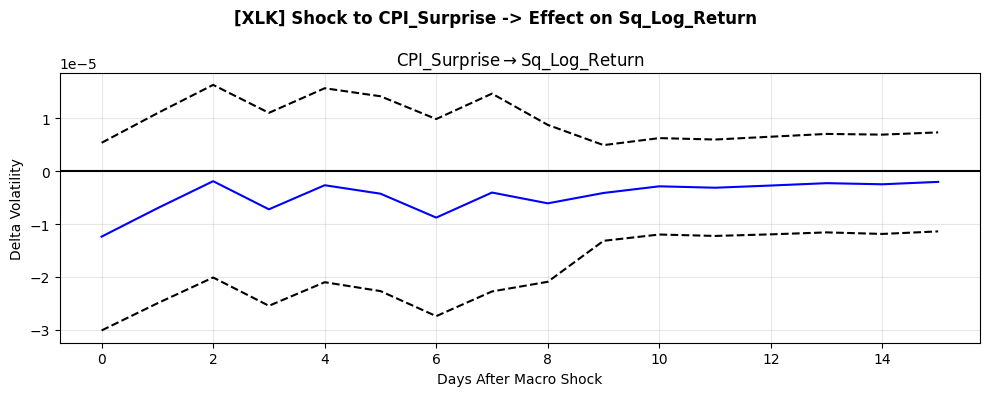

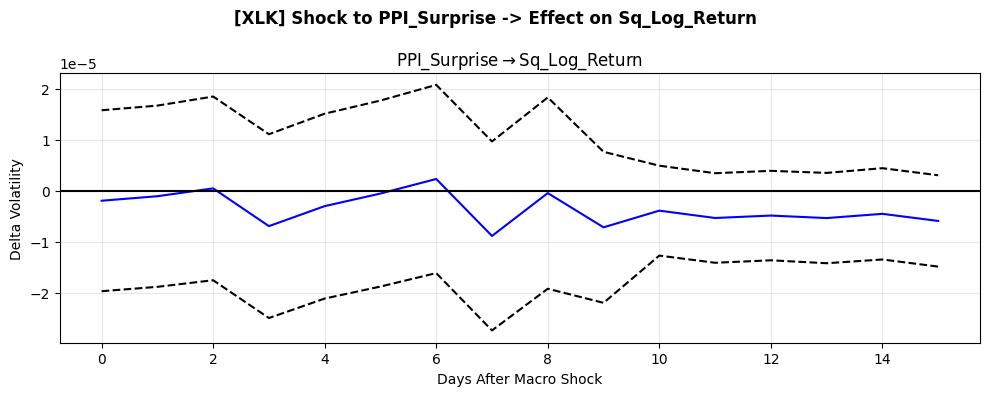

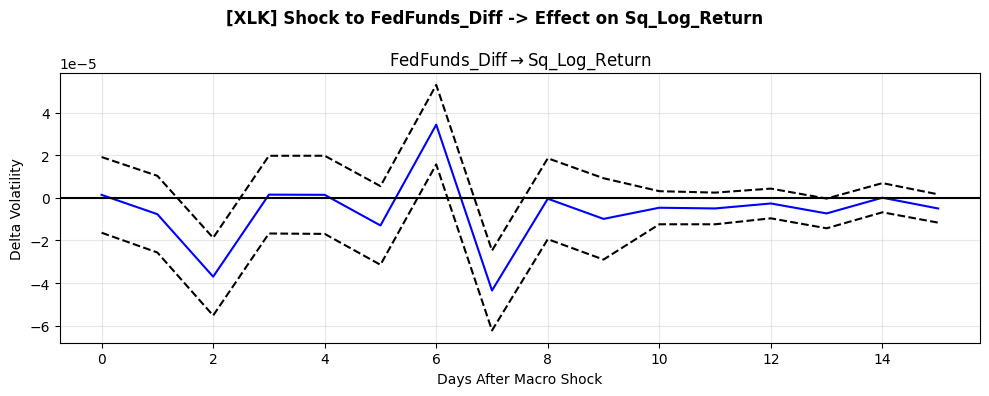

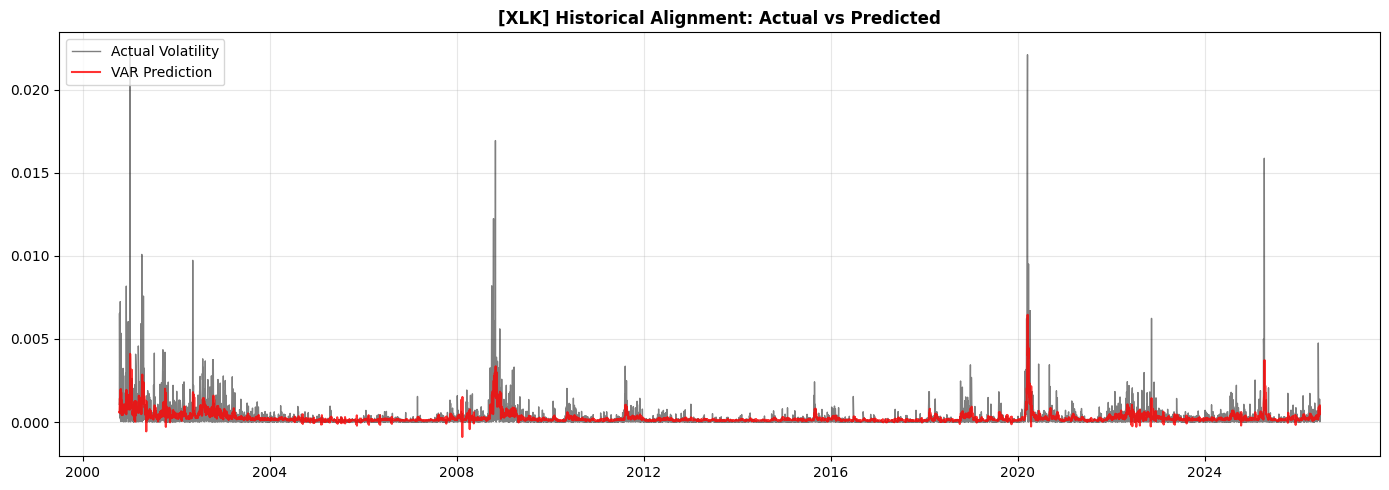


VISUAL DIAGNOSTICS: XLE


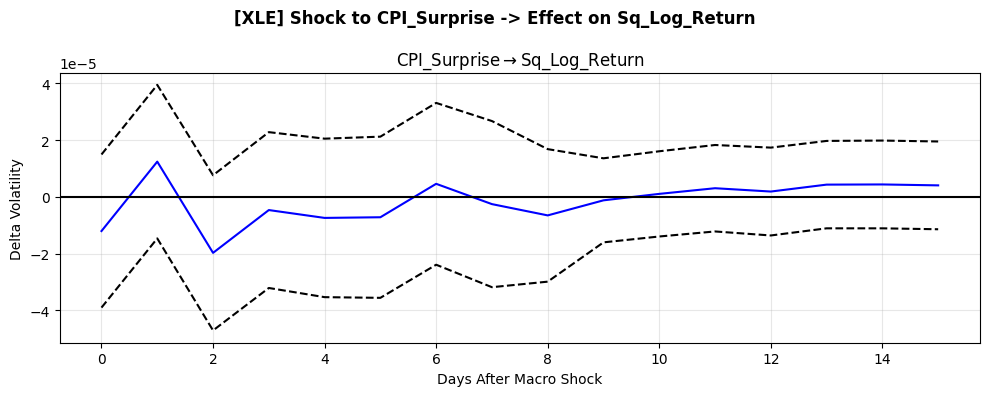

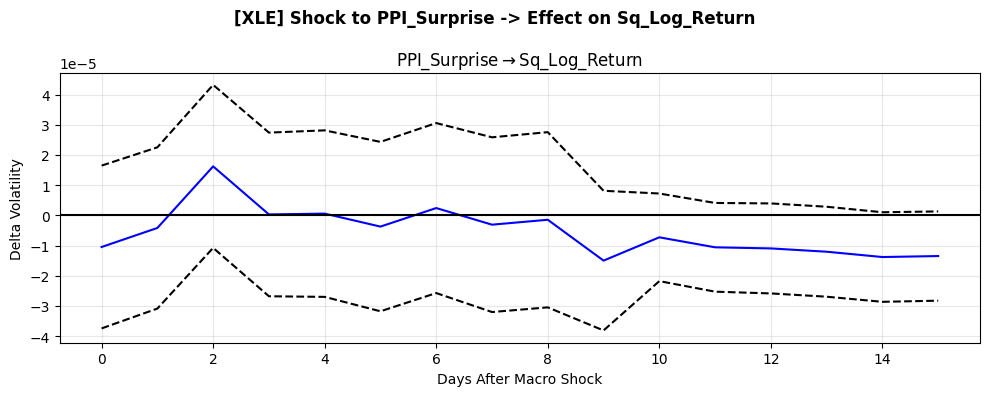

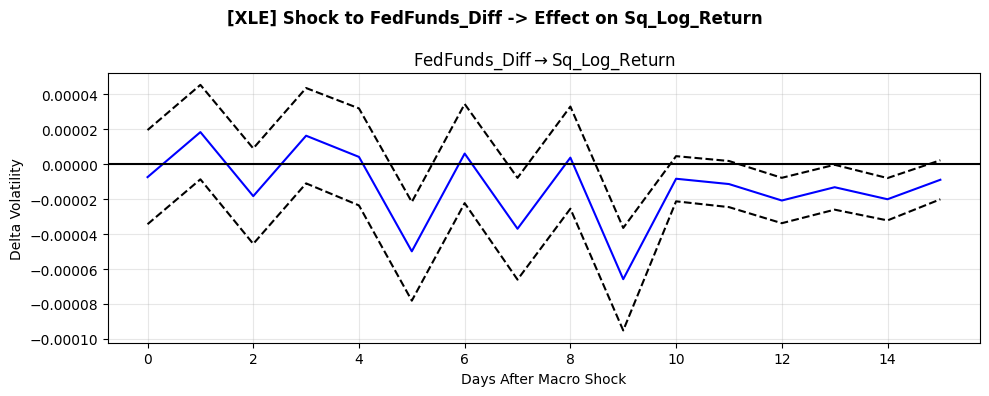

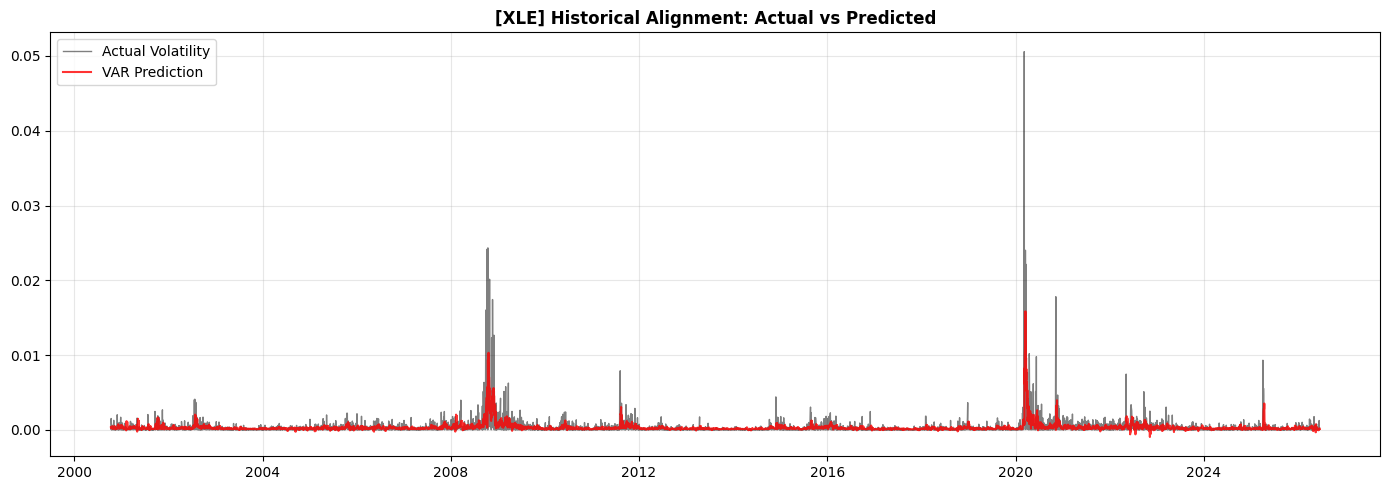


VISUAL DIAGNOSTICS: XLF


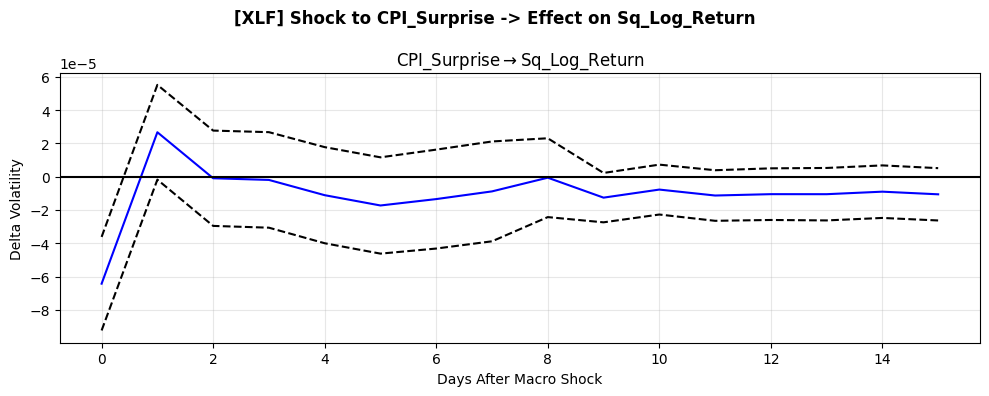

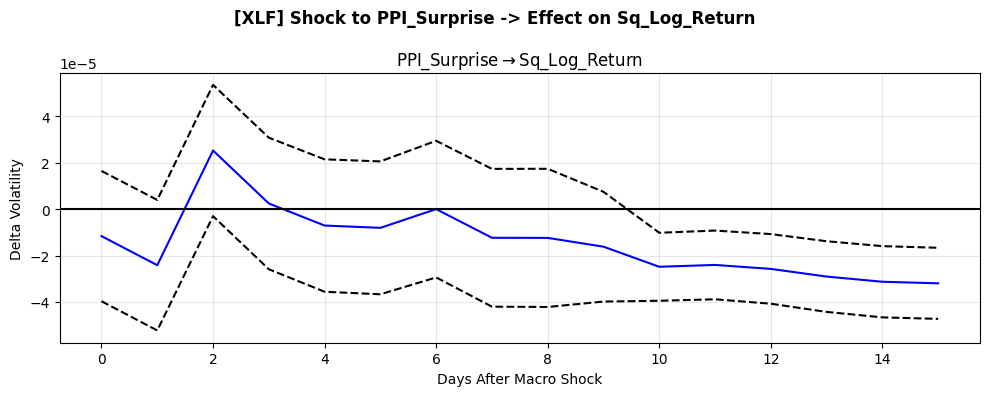

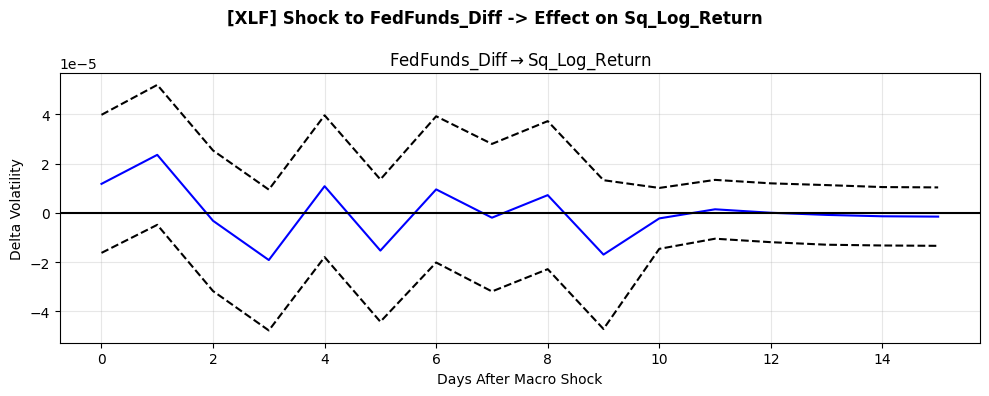

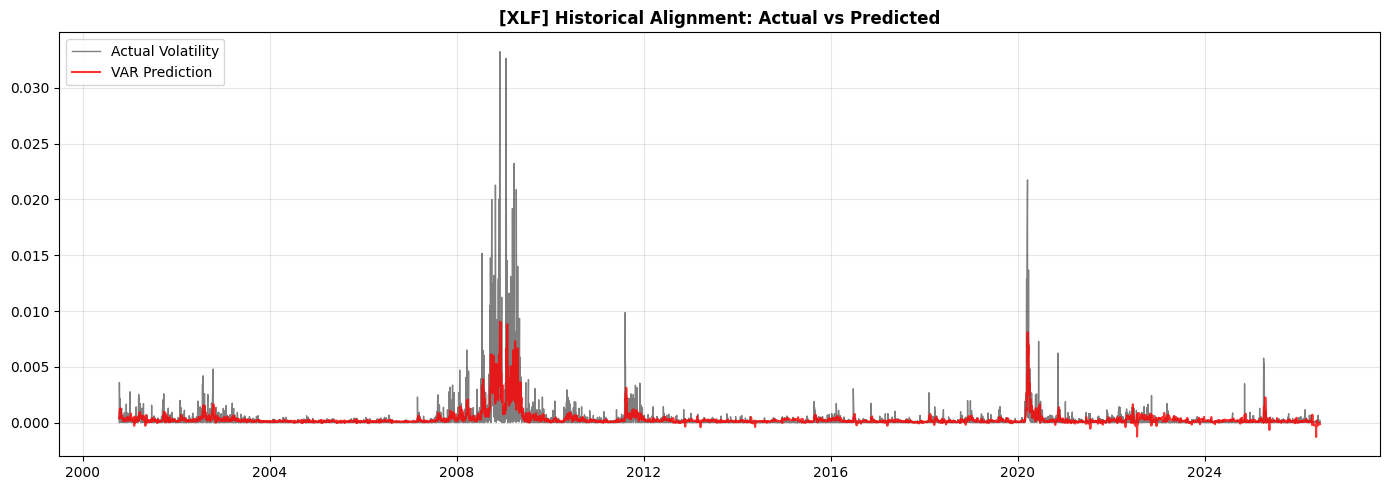


VISUAL DIAGNOSTICS: XLV


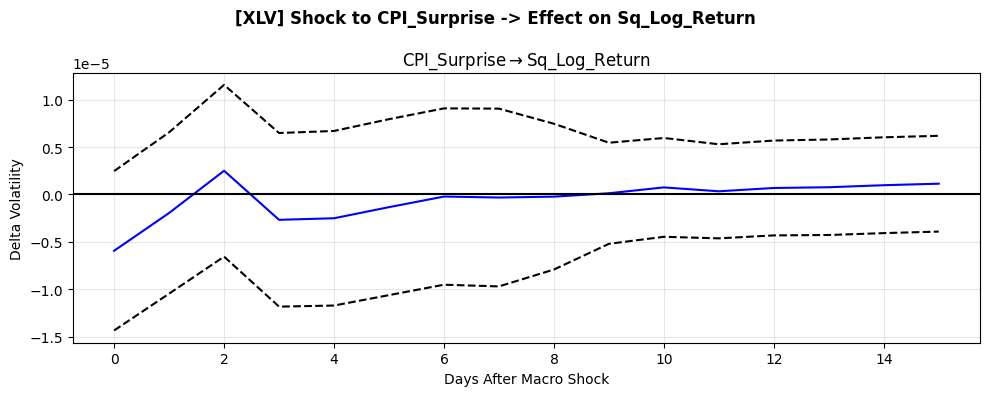

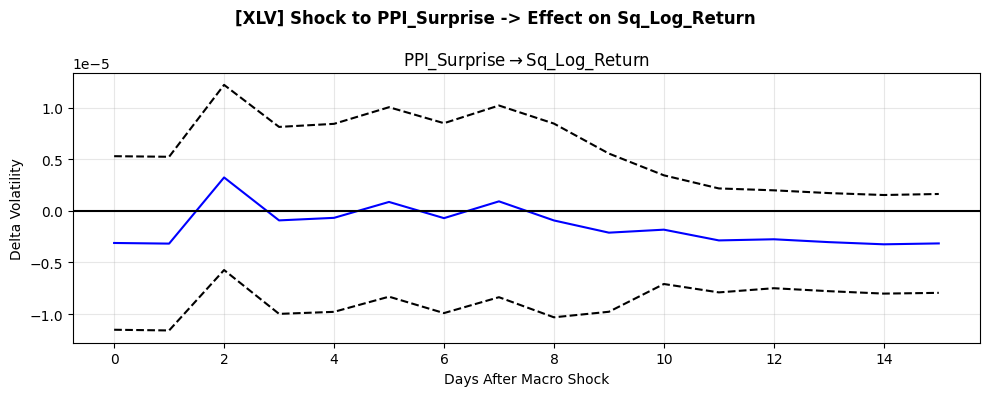

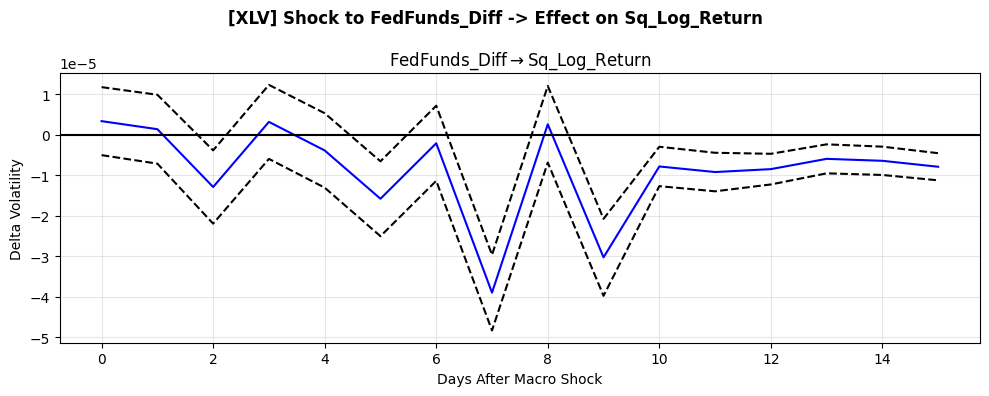

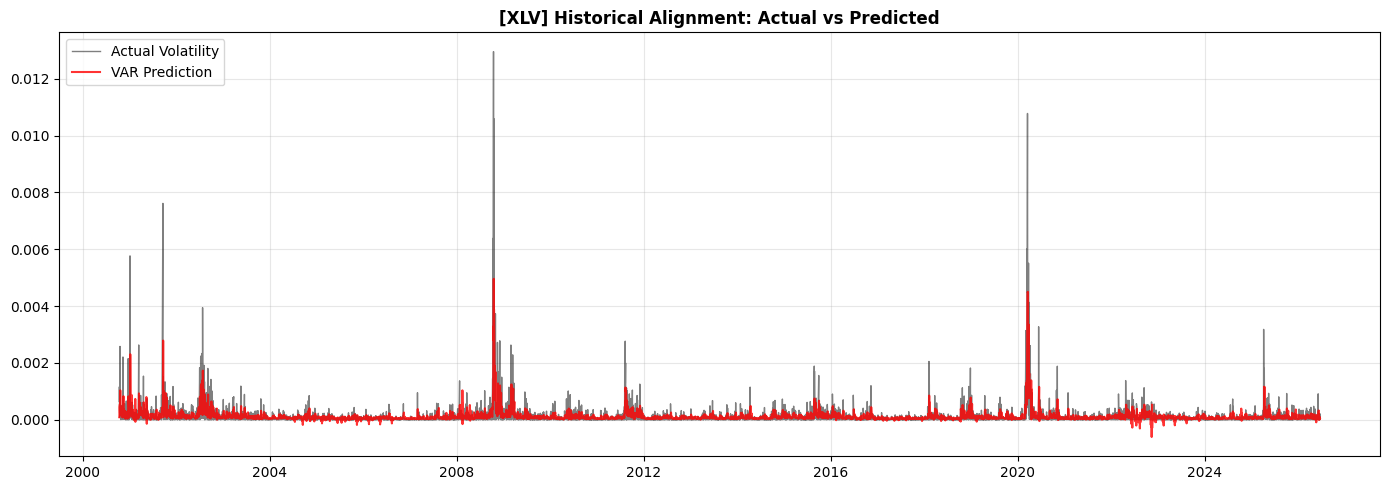

In [5]:
# 4. VISUALIZATIONS
for etf in config.TARGET_ETFS:
    print("\n" + "="*80)
    print(f"VISUAL DIAGNOSTICS: {etf}")
    print("="*80)
    
    results = sector_models[etf]
    var_data = sector_var_data[etf]
    
    econometrics.plot_irfs(results, var_data, sector_name=etf, irf_periods=15)
    econometrics.plot_historical_fit(results, var_data, sector_name=etf)
